In [ ]:
!nvidia-smi
import torch
print(torch.__version__)
print("CUDA:", torch.cuda.is_available())

Wed Apr 22 07:58:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
import torch
print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA build: 12.8
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
# Core requirements
!pip install -q timm==1.0.15 tensorboardX==2.6.2.2 einops==0.8.1 \
    transformers==4.50.0 Pillow==11.1.0 requests==2.32.3 \
    torchinfo matplotlib scikit-learn thop pyyaml kaggle

# mamba_ssm - GPU-only, must compile against your CUDA version
!pip install -q mamba_ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 145.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 128.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.3 which is incompatible.
google-adk 1.29

In [ ]:
import json, os

# Paste your details here
kaggle_username = "your_kaggle_username"   # ← your Kaggle username
kaggle_key = "KGAT_f2df96d2a0f3ec9ec9f62427e3bbc4bb"  # ← your token from the screen

# Create the kaggle.json file
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
kaggle_json = {"username": kaggle_username, "key": kaggle_key}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_json, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("kaggle.json created ✅")

# Then download the dataset
!kaggle datasets download -d aryashah2k/breast-ultrasound-images-dataset
!unzip -q breast-ultrasound-images-dataset.zip -d busi_raw

kaggle.json created ✅
Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:13<00:00, 15.0MB/s]



In [ ]:
# # Option A: if repo is on GitHub
# !git clone https://github.com/YOUR_REPO/ultrascannet_reproduced.git
# %cd ultrascannet_reproduced

# Option B: upload the zip directly
from google.colab import files
files.upload()  # upload ultrascannet_reproduced-main.zip
!unzip -q ultrascannet_reproduced-main.zip
%cd ultrascannet_reproduced-main

Cloning into 'ultrascannet_reproduced'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'ultrascannet_reproduced'
/content


Saving ultrascannet_reproduced-main.zip to ultrascannet_reproduced-main.zip
/content/ultrascannet_reproduced-main


In [ ]:
import yaml

with open("paths.yaml") as f:
    paths = yaml.safe_load(f)

paths["datasets_root"]        = "/content/ultrascannet_reproduced-main/datasets"
paths["busi_split_dir"]       = "/content/ultrascannet_reproduced-main/datasets/BUSI_split"
paths["weights_dir"]          = "/content/ultrascannet_reproduced-main/weights"
paths["ultrascannet_checkpoint"] = "/content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI/model_best.pth.tar"
paths["output_dir"]           = "/content/ultrascannet_reproduced-main/weights"

with open("paths.yaml", "w") as f:
    yaml.dump(paths, f)

print("paths.yaml updated ✅")

paths.yaml updated ✅


In [ ]:
# Tell setup_dataset.py where the raw data already is (skip download)
import shutil, pathlib

raw_dest = pathlib.Path("datasets/raw/Dataset_BUSI_with_GT")
raw_dest.mkdir(parents=True, exist_ok=True)
shutil.copytree("/content/busi_raw/Dataset_BUSI_with_GT", str(raw_dest), dirs_exist_ok=True)

!python3 setup_dataset.py

UltraScanNet — BUSI Dataset Setup
⬇️  Downloading aryashah2k/breast-ultrasound-images-dataset from Kaggle …
Dataset URL: https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset
License(s): CC0-1.0
100% 195M/195M [00:11<00:00, 17.7MB/s]

✅ Download complete → /content/ultrascannet_reproduced-main/datasets/BUSI_raw
✅ Organized split → /content/ultrascannet_reproduced-main/datasets/BUSI_split
   Copied: 780  |  Already present: 0

Verifying split …
  ✅ train/benign: 350/350
  ✅ train/malignant: 168/168
  ✅ train/normal: 106/106
  ✅ validation/benign: 87/87
  ✅ validation/malignant: 42/42
  ✅ validation/normal: 27/27

✅ All files present — dataset ready.


In [ ]:
!python3 setup_weights.py
# If it fails (OneDrive link), manually download from the README link
# and upload to weights/ directory

UltraScanNet — Pretrained Weights Setup

Checking for existing weights …
  ❌ /content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI/model_best.pth.tar
  ❌ /content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI/args.yaml

Attempting automated download …
⚠️  Automated download of OneDrive folder shares is not supported.

MANUAL DOWNLOAD REQUIRED

OneDrive public folder links cannot be downloaded automatically.

Please do the following:

  1. Open this URL in your browser:
     https://uptro29158-my.sharepoint.com/:f:/g/personal/alexandra_laicu-hausberger_student_upt_ro/Em88eUDjtxBKmFMdmV75XBYB-AmQabzwnSjD-IzuwCstqA

  2. Download the folder contents (model_best.pth.tar and args.yaml)
     for the 'ultra_scan_net_BUSI' experiment.

  3. Place the files here:
     /content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI/model_best.pth.tar
     /content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI/args.yaml

  4. Re-run this script to verify, or pr

In [ ]:
import os

# Create weights directory so the training script doesn't complain
os.makedirs("/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI", exist_ok=True)

print("✅ Weights directory ready — pretrained backbone will auto-download from timm during training")

✅ Weights directory ready — pretrained backbone will auto-download from timm during training


In [ ]:
# Fix the KeyError: 'url' in mamba_vision_baseline.py
model_file = "/content/ultrascannet_reproduced-main/ultrascannet/models/mamba_vision_baseline.py"

with open(model_file, "r") as f:
    content = f.read()

old_code = """    if pretrained:
        if not Path(model_path).is_file():
            url = model.default_cfg['url']
            torch.hub.download_url_to_file(url=url, dst=model_path)
        model._load_state_dict(model_path)"""

new_code = """    if pretrained:
        if not Path(model_path).is_file():
            url = default_cfgs['mamba_vision_T2']['url']
            torch.hub.download_url_to_file(url=url, dst=model_path)
        model._load_state_dict(model_path)"""

content = content.replace(old_code, new_code)

with open(model_file, "w") as f:
    f.write(content)

print("✅ Patch applied")

✅ Patch applied


In [ ]:
import os
os.chdir("/content/ultrascannet_reproduced-main/ultrascannet")

!python3 train.py \
    -c configs/experiments/mambavision_tiny2_1k_run_baseline.yaml \
    --model=mamba_vision_T2_baseline \
    --experiment=mamba_vision_T2_baseline_BUSI \
    --data_dir=/content/ultrascannet_reproduced-main/datasets/BUSI_split \
    --data_len=624 \
    --output=/content/ultrascannet_reproduced-main/weights \
    --workers=2 \
    --pretrained

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Training with a single process on 1 GPUs.
100% 402M/402M [00:18<00:00, 23.0MB/s]
The model and loaded state dict do not match exactly

size mismatch for head.weight: copying a param with shape torch.Size([1000, 640]) from checkpoint, the shape in current model is torch.Size([3, 640]).
size mismatch for head.bias: copying a param with shape torch.Size([1000]) from checkpoint, the shape in current model is torch.Size([3]).
Data processing configuration f

In [ ]:
os.chdir("/content/ultrascannet_reproduced-main/ultrascannet")

!python3 val_simple.py \
    --model=mamba_vision_T2_baseline \
    --experiment=mamba_vision_T2_baseline_BUSI \
    --data_dir=/content/ultrascannet_reproduced-main/datasets/BUSI_split \
    --output=/content/ultrascannet_reproduced-main/weights \
    --workers=2

Training with a single process on 1 GPUs.
mamba_vision_T2_baseline: 35.104008 | 35.104008
Data processing configuration for current model + dataset:
	input_size: (3, 224, 224)
	interpolation: bicubic
	mean: (0.485, 0.456, 0.406)
	std: (0.229, 0.224, 0.225)
	crop_pct: 0.875
	crop_mode: center
AMP not enabled. Training in float32.
Loading checkpoint , checking for existing parameters if their shape match
Traceback (most recent call last):
  File "/content/ultrascannet_reproduced-main/ultrascannet/val_simple.py", line 1130, in <module>
    main()
  File "/content/ultrascannet_reproduced-main/ultrascannet/val_simple.py", line 602, in main
    new_model_weights = torch.load(args.loadcheckpoint, weights_only=False)["state_dict"]
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1500, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lo

In [ ]:
# Find where the checkpoint was saved
!find /content/ultrascannet_reproduced-main/weights -name "*.pth.tar" -o -name "*.pth" 2>/dev/null

/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/model_best.pth.tar
/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/last.pth.tar
/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/checkpoint-56.pth.tar


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# Create a folder in your Drive
save_dir = "/content/drive/MyDrive/ultrascannet_baseline"
os.makedirs(save_dir, exist_ok=True)

# Copy all important files
files_to_save = [
    "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/model_best.pth.tar",
    "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/last.pth.tar",
    "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/checkpoint-56.pth.tar",
]

for f in files_to_save:
    dest = os.path.join(save_dir, os.path.basename(f))
    shutil.copy(f, dest)
    print(f"✅ Saved: {os.path.basename(f)}")

# Also save the summary/metrics if they exist
summary = "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/summary.csv"
best_txt = "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/best.txt"
for f in [summary, best_txt]:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(save_dir, os.path.basename(f)))
        print(f"✅ Saved: {os.path.basename(f)}")

print(f"\n📁 All files saved to Google Drive: {save_dir}")

Mounted at /content/drive
✅ Saved: model_best.pth.tar
✅ Saved: last.pth.tar
✅ Saved: checkpoint-56.pth.tar
✅ Saved: summary.csv
✅ Saved: best.txt

📁 All files saved to Google Drive: /content/drive/MyDrive/ultrascannet_baseline


In [ ]:
import torch

ckpt = torch.load(
    "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/model_best.pth.tar",
    weights_only=False
)

print("Keys in checkpoint:", ckpt.keys())
if 'epoch' in ckpt:
    print("Saved at epoch:", ckpt['epoch'])
if 'top1' in ckpt or 'best_metric' in ckpt:
    print("Best metric:", ckpt.get('top1') or ckpt.get('best_metric'))
if 'state_dict' in ckpt:
    keys = list(ckpt['state_dict'].keys())
    print("First 5 state_dict keys:", keys[:5])

Keys in checkpoint: dict_keys(['epoch', 'arch', 'state_dict', 'optimizer', 'version', 'args', 'amp_scaler', 'metric'])
Saved at epoch: 56
First 5 state_dict keys: ['patch_embed.conv_down.0.weight', 'patch_embed.conv_down.1.weight', 'patch_embed.conv_down.1.bias', 'patch_embed.conv_down.1.running_mean', 'patch_embed.conv_down.1.running_var']


In [ ]:
!cat /content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/best.txt

Experiment mamba_vision_T2_baseline_BUSI - best_top1=90.38461577586638 at step=56

In [ ]:
!python3 /content/ultrascannet_reproduced-main/ultrascannet/val_simple.py --help 2>&1 | head -60

usage: val_simple.py [-h] [--data_dir DIR] [--dataset NAME]
                     [--train-split NAME] [--val-split NAME]
                     [--dataset-download] [--class-map FILENAME] [--tag TAG]
                     [--model MODEL] [--pretrained]
                     [--initial-checkpoint PATH] [--resume PATH]
                     [--loadcheckpoint PATH] [--no-resume-opt]
                     [--num-classes N] [--gp POOL] [--img-size N]
                     [--input-size N N N N N N N N N] [--crop-pct N]
                     [--mean MEAN [MEAN ...]] [--std STD [STD ...]]
                     [--interpolation NAME] [-b N] [-vb N] [--channels-last]
                     [--torchscript | --aot-autograd] [--fuser FUSER]
                     [--grad-checkpointing] [--opt OPTIMIZER]
                     [--opt-eps EPSILON] [--opt-betas BETA [BETA ...]]
                     [--momentum M] [--weight-decay WEIGHT_DECAY]
                     [--clip-grad NORM] [--clip-mode CLIP_MODE]
         

In [ ]:
!cat /content/ultrascannet_reproduced-main/ultrascannet/launch_validation.py

#!/usr/bin/env python3
"""
launch_validation.py
Validates trained models on BUSI. All paths are read from paths.yaml at the repo root.

Expects checkpoints at:
    <weights_dir>/<model>_<dataset>/model_best.pth.tar
    <weights_dir>/<model>_<dataset>/args.yaml
"""

import subprocess
import sys
from pathlib import Path

import yaml

REPO_ROOT = Path(__file__).parent.parent
PATHS_YAML = REPO_ROOT / "paths.yaml"


def resolve_repo_path(path_value: str) -> str:
    path = Path(path_value)
    if path.is_absolute():
        return str(path)
    return str((REPO_ROOT / path).resolve())


def load_paths():
    with open(PATHS_YAML) as f:
        paths = yaml.safe_load(f)

    for key in ("datasets_root", "busi_split_dir", "weights_dir", "ultrascannet_checkpoint", "output_dir"):
        if key in paths:
            paths[key] = resolve_repo_path(paths[key])
    return paths


def main():
    paths = load_paths()
    busi_dir = paths["busi_split_dir"]
    output_dir = Path(paths["output_dir"])


In [ ]:
import shutil

# The args.yaml is saved during training alongside the checkpoint
# If not there, copy from the config
src = "/content/ultrascannet_reproduced-main/ultrascannet/configs/experiments/mambavision_tiny2_1k_run_baseline.yaml"
dst = "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/args.yaml"

shutil.copy(src, dst)
print("✅ args.yaml placed")

# Verify both files exist
!ls -lh /content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/

✅ args.yaml placed
total 1.2G
-rw-r--r-- 1 root root 2.3K Apr 22 08:55 args.yaml
-rw-r--r-- 1 root root   81 Apr 22 08:38 best.txt
-rw-r--r-- 2 root root 395M Apr 22 08:37 checkpoint-56.pth.tar
drwxr-xr-x 6 root root 4.0K Apr 22 08:32 code_copy
-rw-r--r-- 1 root root 395M Apr 22 08:38 last.pth.tar
-rw-r--r-- 2 root root 395M Apr 22 08:37 model_best.pth.tar
-rw-r--r-- 1 root root 3.0K Apr 22 08:32 model_statistics.txt
-rw-r--r-- 1 root root  19K Apr 22 08:32 model.txt
-rw-r--r-- 1 root root 4.4K Apr 22 08:38 summary.csv


In [ ]:
val_file = "/content/ultrascannet_reproduced-main/ultrascannet/launch_validation.py"

with open(val_file, "r") as f:
    content = f.read()

old = '''    model_list = [
        "ultra_scan_net",
        # "mamba_vision_T2_baseline",'''

new = '''    model_list = [
        # "ultra_scan_net",
        "mamba_vision_T2_baseline",'''

content = content.replace(old, new)

with open(val_file, "w") as f:
    f.write(content)

print("✅ launch_validation.py patched")

✅ launch_validation.py patched


In [ ]:
import os
os.chdir("/content/ultrascannet_reproduced-main/ultrascannet")

!python3 launch_validation.py


✅ Validating: mamba_vision_T2_baseline_BUSI

Training with a single process on 1 GPUs.
The model and loaded state dict do not match exactly

size mismatch for head.weight: copying a param with shape torch.Size([1000, 640]) from checkpoint, the shape in current model is torch.Size([3, 640]).
size mismatch for head.bias: copying a param with shape torch.Size([1000]) from checkpoint, the shape in current model is torch.Size([3]).
mamba_vision_T2_baseline: 34.464931 | 34.464931
Data processing configuration for current model + dataset:
	input_size: (3, 224, 224)
	interpolation: bicubic
	mean: (0.485, 0.456, 0.406)
	std: (0.229, 0.224, 0.225)
	crop_pct: 1.0
	crop_mode: center
Using native Torch AMP. Training in mixed precision.
Loading checkpoint /content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/model_best.pth.tar, checking for existing parameters if their shape match
Test: [   0/9]  Time: 4.999 (4.999)  Loss:  0.1821 (0.1821)  Acc@1: 100.0000 (100.0000)  Acc@5: 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# Create folder in Drive
save_dir = "/content/drive/MyDrive/ultrascannet_baseline"
os.makedirs(save_dir, exist_ok=True)

# Save evaluation metrics JSON
shutil.copy(
    "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/evaluation_metrics.json",
    f"{save_dir}/evaluation_metrics.json"
)

# Save best checkpoint
shutil.copy(
    "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/model_best.pth.tar",
    f"{save_dir}/model_best.pth.tar"
)

# Save training summary
shutil.copy(
    "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/summary.csv",
    f"{save_dir}/summary.csv"
)

# Save best.txt
shutil.copy(
    "/content/ultrascannet_reproduced-main/weights/mamba_vision_T2_baseline_BUSI/best.txt",
    f"{save_dir}/best.txt"
)

print("✅ All files saved to Google Drive!")
print(f"📁 Location: {save_dir}")
!ls -lh "{save_dir}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All files saved to Google Drive!
📁 Location: /content/drive/MyDrive/ultrascannet_baseline
total 1.2G
-rw------- 1 root root   81 Apr 22 09:16 best.txt
-rw------- 1 root root 395M Apr 22 08:49 checkpoint-56.pth.tar
-rw------- 1 root root 2.4K Apr 22 09:16 evaluation_metrics.json
-rw------- 1 root root 395M Apr 22 08:49 last.pth.tar
-rw------- 1 root root 395M Apr 22 09:16 model_best.pth.tar
-rw------- 1 root root 4.4K Apr 22 09:16 summary.csv


In [ ]:
exp_file = "/content/ultrascannet_reproduced-main/ultrascannet/launch_experiments.py"

with open(exp_file, "r") as f:
    content = f.read()

old = '''    model_list = [
        "ultra_scan_net",
        # "mamba_vision_T2_baseline",'''

new = '''    model_list = [
        # "mamba_vision_T2_baseline",
        "ultra_scan_net",'''

content = content.replace(old, new)

with open(exp_file, "w") as f:
    f.write(content)

print("✅ launch_experiments.py ready for UltraScanNet")

✅ launch_experiments.py ready for UltraScanNet


In [ ]:
import os

# Delete previous runs completely
!rm -rf /content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI

os.chdir("/content/ultrascannet_reproduced-main/ultrascannet")

!python3 train.py \
    -c configs/experiments/mambavision_tiny2_1k_run_exp.yaml \
    --model=ultra_scan_net \
    --experiment=ultra_scan_net_BUSI \
    --data_dir=/content/ultrascannet_reproduced-main/datasets/BUSI_split \
    --data_len=624 \
    --output=/content/ultrascannet_reproduced-main/weights \
    --workers=2

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Training with a single process on 1 GPUs.
Layer scale conv None
First layer convblock_posenc
⚠️ Skipping classifier head due to num_classes mismatch (1000 in checkpoint vs 3 in model)
The model and loaded state dict do not match exactly

unexpected key in source state_dict: levels.1.blocks.2.conv1.weight, levels.1.blocks.2.conv1.bias, levels.1.blocks.2.norm1.weight, levels.1.blocks.2.norm1.bias, levels.1.blocks.2.norm1.running_mean, levels.1.blocks.2.n

In [ ]:
import os

!rm -rf /content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI

os.chdir("/content/ultrascannet_reproduced-main/ultrascannet")

!python3 train.py \
    -c configs/experiments/mambavision_tiny2_1k_run_exp.yaml \
    --model=ultra_scan_net \
    --experiment=ultra_scan_net_BUSI \
    --data_dir=/content/ultrascannet_reproduced-main/datasets/BUSI_split \
    --data_len=624 \
    --output=/content/ultrascannet_reproduced-main/weights \
    --workers=2 \
    --patience-epochs=150

/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Training with a single process on 1 GPUs.
Layer scale conv None
First layer convblock_posenc
⚠️ Skipping classifier head due to num_classes mismatch (1000 in checkpoint vs 3 in model)
The model and loaded state dict do not match exactly

unexpected key in source state_dict: levels.1.blocks.2.conv1.weight, levels.1.blocks.2.conv1.bias, levels.1.blocks.2.norm1.weight, levels.1.blocks.2.norm1.bias, levels.1.blocks.2.norm1.running_mean, levels.1.blocks.2.n

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

save_dir = "/content/drive/MyDrive/ultrascannet_baseline/ultra_scan_net_full_run"
os.makedirs(save_dir, exist_ok=True)

files = [
    "model_best.pth.tar",
    "last.pth.tar",
    "summary.csv",
    "best.txt"
]

base = "/content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI"
for f in files:
    src = os.path.join(base, f)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(save_dir, f))
        print(f"✅ Saved: {f}")

print(f"\n📁 All saved to Drive: {save_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved: model_best.pth.tar
✅ Saved: last.pth.tar
✅ Saved: summary.csv
✅ Saved: best.txt

📁 All saved to Drive: /content/drive/MyDrive/ultrascannet_baseline/ultra_scan_net_full_run


In [ ]:
val_file = "/content/ultrascannet_reproduced-main/ultrascannet/launch_validation.py"

with open(val_file, "r") as f:
    content = f.read()

old = '''    model_list = [
        # "ultra_scan_net",
        "mamba_vision_T2_baseline",'''

new = '''    model_list = [
        "ultra_scan_net",
        # "mamba_vision_T2_baseline",'''

content = content.replace(old, new)

with open(val_file, "w") as f:
    f.write(content)

print("launch_validation.py ready for UltraScanNet")

launch_validation.py ready for UltraScanNet


In [ ]:
import shutil

shutil.copy(
    "/content/ultrascannet_reproduced-main/ultrascannet/configs/experiments/mambavision_tiny2_1k_run_exp.yaml",
    "/content/ultrascannet_reproduced-main/weights/ultra_scan_net_BUSI/args.yaml"
)
print("✅ args.yaml placed")

✅ args.yaml placed


In [ ]:
import os
os.chdir("/content/ultrascannet_reproduced-main/ultrascannet")

!python3 launch_validation.py


✅ Validating: ultra_scan_net_BUSI

Training with a single process on 1 GPUs.
Layer scale conv None
First layer convblock_posenc
⚠️ Skipping classifier head due to num_classes mismatch (1000 in checkpoint vs 3 in model)
The model and loaded state dict do not match exactly

unexpected key in source state_dict: levels.1.blocks.2.conv1.weight, levels.1.blocks.2.conv1.bias, levels.1.blocks.2.norm1.weight, levels.1.blocks.2.norm1.bias, levels.1.blocks.2.norm1.running_mean, levels.1.blocks.2.norm1.running_var, levels.1.blocks.2.norm1.num_batches_tracked, levels.1.blocks.2.conv2.weight, levels.1.blocks.2.conv2.bias, levels.1.blocks.2.norm2.weight, levels.1.blocks.2.norm2.bias, levels.1.blocks.2.norm2.running_mean, levels.1.blocks.2.norm2.running_var, levels.1.blocks.2.norm2.num_batches_tracked, levels.2.blocks.4.mixer.A_log, levels.2.blocks.4.mixer.D, levels.2.blocks.4.mixer.in_proj.weight, levels.2.blocks.4.mixer.x_proj.weight, levels.2.blocks.4.mixer.dt_proj.weight, levels.2.blocks.4.mixer.

Summary DataFrame head:
   epoch  train_loss  eval_loss  eval_top1  eval_top5
0      0    1.091870   1.190843  18.589744      100.0
1      1    1.090445   1.135567  24.358974      100.0
2      2    1.093768   1.110965  27.564103      100.0
3      3    1.082364   1.115798  23.717949      100.0
4      4    1.078362   1.107222  26.282052      100.0

Summary DataFrame columns:
Index(['epoch', 'train_loss', 'eval_loss', 'eval_top1', 'eval_top5'], dtype='object')
Note: Training accuracy column ('train_top1') not found in summary.csv. Plotting only validation accuracy.


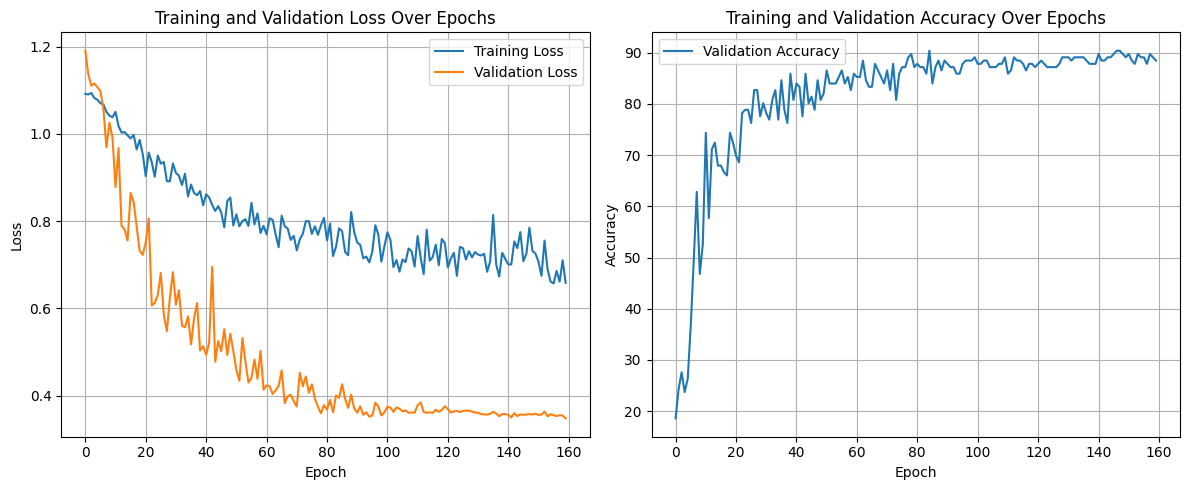

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define the path to the summary.csv file
summary_csv_path = "/content/drive/MyDrive/ultrascannet_baseline/ultra_scan_net_full_run/summary.csv"

# Check if the file exists before attempting to load it
if os.path.exists(summary_csv_path):
    # Load the summary.csv file
    summary_df = pd.read_csv(summary_csv_path)

    # Display the first few rows and column names to understand the structure
    print("Summary DataFrame head:")
    print(summary_df.head())
    print("\nSummary DataFrame columns:")
    print(summary_df.columns)

    # Plotting training and validation loss
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(summary_df['epoch'], summary_df['train_loss'], label='Training Loss')
    plt.plot(summary_df['epoch'], summary_df['eval_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)

    # Plotting training and validation accuracy
    plt.subplot(1, 2, 2)
    if 'train_top1' in summary_df.columns and 'eval_top1' in summary_df.columns:
        plt.plot(summary_df['epoch'], summary_df['train_top1'], label='Training Accuracy')
        plt.plot(summary_df['epoch'], summary_df['eval_top1'], label='Validation Accuracy')
    elif 'eval_top1' in summary_df.columns:
        # Fallback if only validation accuracy is available
        plt.plot(summary_df['epoch'], summary_df['eval_top1'], label='Validation Accuracy')
        print("Note: Training accuracy column ('train_top1') not found in summary.csv. Plotting only validation accuracy.")
    else:
        print("Accuracy columns ('train_top1' or 'eval_top1') not found in summary.csv. Skipping accuracy plot.")

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

else:
    print(f"Error: The file {summary_csv_path} was not found. Please ensure the training was completed successfully and the file exists.")